# Exploratory Data Analysis — MAP Homicide Dataset
**Murder Accountability Project · Supplementary Homicide Report (1980–2014)**

This notebook performs a simple EDA on the MAP dataset to understand the structure, distributions, and patterns in U.S. homicide data — with an eye toward its suitability for crime linkage modeling.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 30)

In [2]:
df = pd.read_csv("HomocideData.csv", low_memory=False)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 638,454 rows × 24 columns


,Record ID,Agency Code,Agency Name,Agency Type,City,State,Year,Month,Incident,Crime Type,Crime Solved,Victim Sex,Victim Age,Victim Race,Victim Ethnicity,Perpetrator Sex,Perpetrator Age,Perpetrator Race,Perpetrator Ethnicity,Relationship,Weapon,Victim Count,Perpetrator Count,Record Source
0,1,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,January,1,Murder or Manslaughter,Yes,Male,14,Native American/Alaska Native,Unknown,Male,15,Native American/Alaska Native,Unknown,Acquaintance,Blunt Object,0,0,FBI
1,2,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,1,Murder or Manslaughter,Yes,Male,43,White,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
2,3,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,March,2,Murder or Manslaughter,No,Female,30,Native American/Alaska Native,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,0,FBI
3,4,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,1,Murder or Manslaughter,Yes,Male,43,White,Unknown,Male,42,White,Unknown,Acquaintance,Strangulation,0,0,FBI
4,5,AK00101,Anchorage,Municipal Police,Anchorage,Alaska,1980,April,2,Murder or Manslaughter,No,Female,30,Native American/Alaska Native,Unknown,Unknown,0,Unknown,Unknown,Unknown,Unknown,0,1,FBI


## 2. Basic Info & Missing Values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 638454 entries, 0 to 638453
Data columns (total 24 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   Record ID              638454 non-null  int64
 1   Agency Code            638454 non-null  str  
 2   Agency Name            638454 non-null  str  
 3   Agency Type            638454 non-null  str  
 4   City                   638454 non-null  str  
 5   State                  638454 non-null  str  
 6   Year                   638454 non-null  int64
 7   Month                  638454 non-null  str  
 8   Incident               638454 non-null  int64
 9   Crime Type             638454 non-null  str  
 10  Crime Solved           638454 non-null  str  
 11  Victim Sex             638454 non-null  str  
 12  Victim Age             638454 non-null  int64
 13  Victim Race            638454 non-null  str  
 14  Victim Ethnicity       638454 non-null  str  
 15  Perpetrator Sex        63845

In [4]:
# Check for missing / null values
df.isnull().sum()

Record ID                0
Agency Code              0
Agency Name              0
Agency Type              0
City                     0
State                    0
Year                     0
Month                    0
Incident                 0
Crime Type               0
Crime Solved             0
Victim Sex               0
Victim Age               0
Victim Race              0
Victim Ethnicity         0
Perpetrator Sex          0
Perpetrator Age          0
Perpetrator Race         0
Perpetrator Ethnicity    0
Relationship             0
Weapon                   0
Victim Count             0
Perpetrator Count        0
Record Source            0
dtype: int64

In [5]:
# Summary statistics for numeric columns
df.describe()

,Record ID,Year,Incident,Victim Age,Victim Count,Perpetrator Count
count,638454.00000,638454.000000,638454.000000,638454.000000,638454.000000,638454.000000
mean,319227.50000,1995.801102,22.967924,35.033512,0.123334,0.185224
std,184305.93872,9.927693,92.149821,41.628306,0.537733,0.585496
min,1.00000,1980.000000,0.000000,0.000000,0.000000,0.000000
25%,159614.25000,1987.000000,1.000000,22.000000,0.000000,0.000000
50%,319227.50000,1995.000000,2.000000,30.000000,0.000000,0.000000
75%,478840.75000,2004.000000,10.000000,42.000000,0.000000,0.000000
max,638454.00000,2014.000000,999.000000,998.000000,10.000000,10.000000


In [6]:
# Unique values per column
for col in df.columns:
    print(f"{col:25s} → {df[col].nunique():>6,} unique values")

Record ID                 → 638,454 unique values
Agency Code               → 12,003 unique values
Agency Name               →  9,216 unique values
Agency Type               →      7 unique values
City                      →  1,782 unique values
State                     →     51 unique values
Year                      →     35 unique values
Month                     →     12 unique values
Incident                  →  1,000 unique values
Crime Type                →      2 unique values
Crime Solved              →      2 unique values
Victim Sex                →      3 unique values
Victim Age                →    101 unique values
Victim Race               →      5 unique values
Victim Ethnicity          →      3 unique values
Perpetrator Sex           →      3 unique values
Perpetrator Age           →    101 unique values
Perpetrator Race          →      5 unique values
Perpetrator Ethnicity     →      3 unique values
Relationship              →     28 unique values
Weapon             

## 3. Crime Solved (Target Variable)

Crime Solved
Yes    448172
No     190282
Name: count, dtype: int64

Clearance Rate: 70.2%


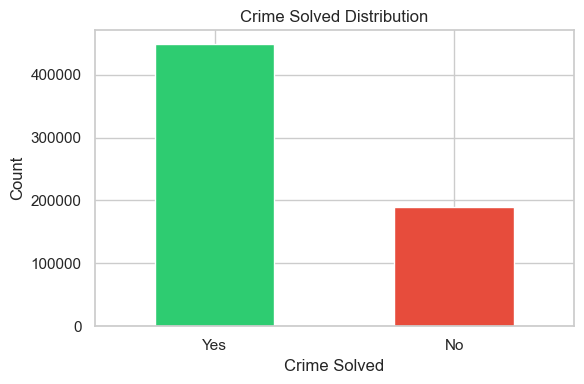

In [7]:
solved_counts = df['Crime Solved'].value_counts()
print(solved_counts)
print(f"\nClearance Rate: {solved_counts['Yes'] / len(df) * 100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
solved_counts.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white', ax=ax)
ax.set_title('Crime Solved Distribution')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 4. Temporal Analysis

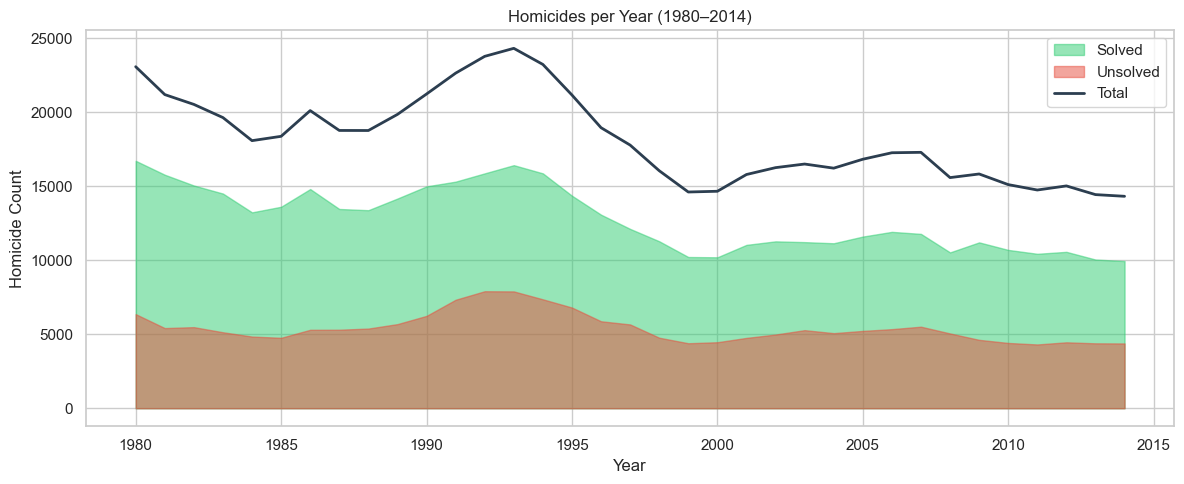

In [8]:
# Homicides per year — solved vs unsolved
yearly = df.groupby(['Year', 'Crime Solved']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(yearly.index, 0, yearly['Yes'], alpha=0.5, label='Solved', color='#2ecc71')
ax.fill_between(yearly.index, 0, yearly['No'], alpha=0.5, label='Unsolved', color='#e74c3c')
ax.plot(yearly.sum(axis=1).index, yearly.sum(axis=1).values, color='#2c3e50', lw=2, label='Total')
ax.set_xlabel('Year')
ax.set_ylabel('Homicide Count')
ax.set_title('Homicides per Year (1980–2014)')
ax.legend()
plt.tight_layout()
plt.show()

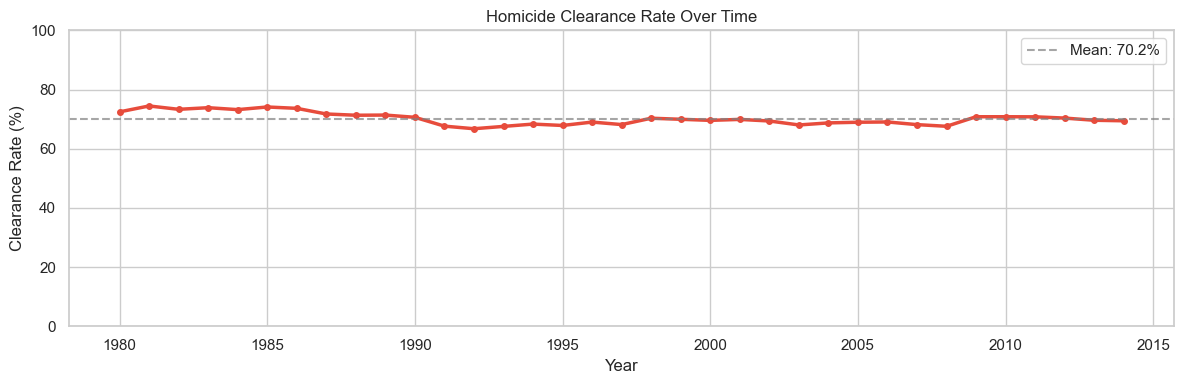

In [9]:
# Clearance rate over time
clearance = (yearly['Yes'] / yearly.sum(axis=1) * 100)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(clearance.index, clearance.values, color='#e74c3c', lw=2.5, marker='o', markersize=4)
ax.axhline(y=clearance.mean(), color='gray', ls='--', alpha=0.7, label=f'Mean: {clearance.mean():.1f}%')
ax.set_xlabel('Year')
ax.set_ylabel('Clearance Rate (%)')
ax.set_title('Homicide Clearance Rate Over Time')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()

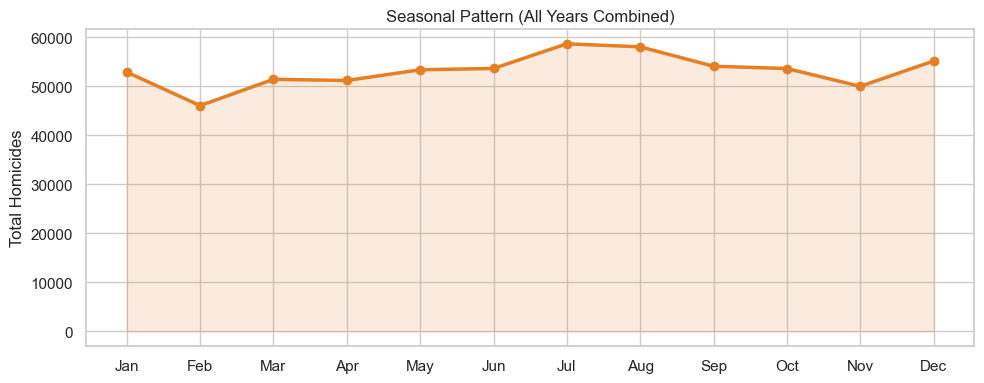

In [10]:
# Seasonal pattern
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly = df.groupby('Month').size().reindex(month_order)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(12), monthly.values, marker='o', lw=2.5, color='#e67e22')
ax.fill_between(range(12), monthly.values, alpha=0.15, color='#e67e22')
ax.set_xticks(range(12))
ax.set_xticklabels([m[:3] for m in month_order])
ax.set_ylabel('Total Homicides')
ax.set_title('Seasonal Pattern (All Years Combined)')
plt.tight_layout()
plt.show()

## 5. Victim Demographics

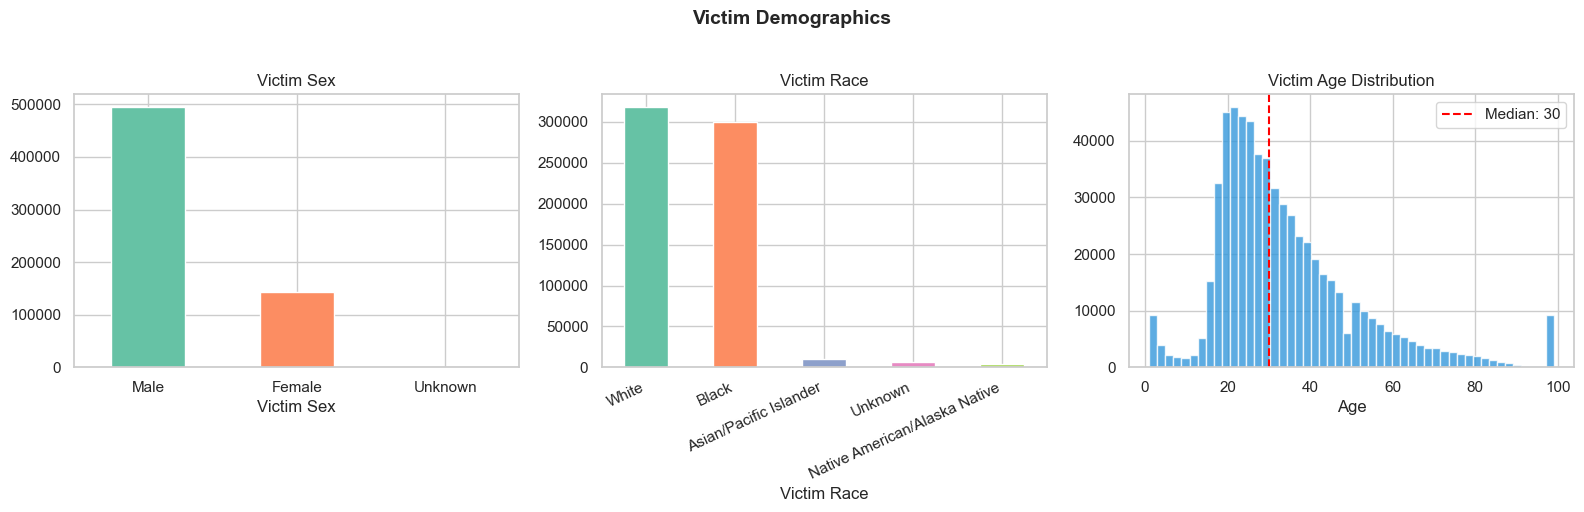

Victim Age — Mean: 34.0, Median: 30, Std: 17.5


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Sex
df['Victim Sex'].value_counts().plot(kind='bar', ax=axes[0], color=sns.color_palette("Set2"))
axes[0].set_title('Victim Sex')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Race
df['Victim Race'].value_counts().plot(kind='bar', ax=axes[1], color=sns.color_palette("Set2"))
axes[1].set_title('Victim Race')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha='right')

# Age
victim_age = pd.to_numeric(df['Victim Age'], errors='coerce')
victim_age = victim_age[(victim_age > 0) & (victim_age < 100)]
axes[2].hist(victim_age, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[2].axvline(victim_age.median(), color='red', ls='--', label=f'Median: {victim_age.median():.0f}')
axes[2].set_xlabel('Age')
axes[2].set_title('Victim Age Distribution')
axes[2].legend()

plt.suptitle('Victim Demographics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Victim Age — Mean: {victim_age.mean():.1f}, Median: {victim_age.median():.0f}, Std: {victim_age.std():.1f}")

## 6. Weapon Analysis

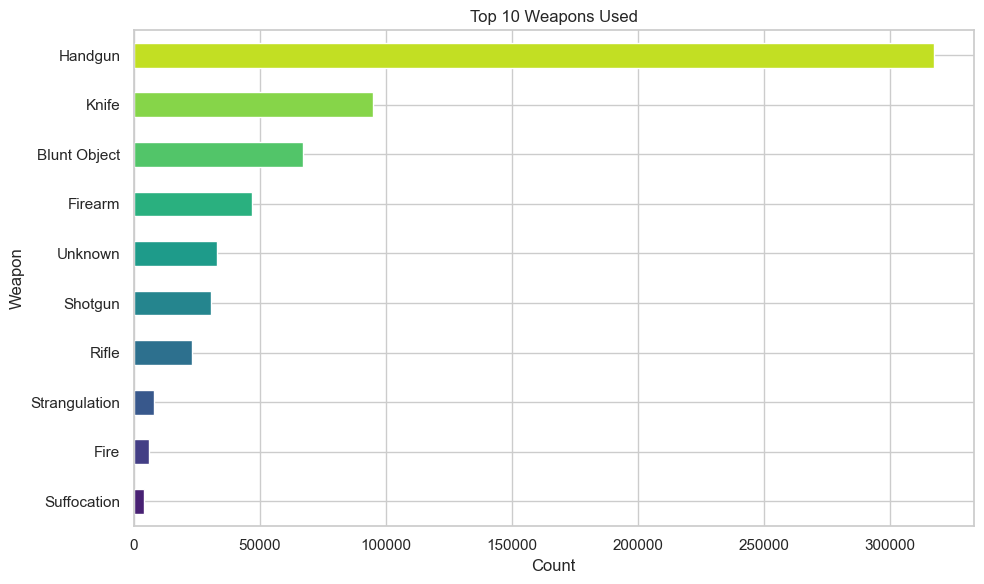

Weapon
Handgun          317484
Knife             94962
Blunt Object      67337
Firearm           46980
Unknown           33192
Shotgun           30722
Rifle             23347
Strangulation      8110
Fire               6173
Suffocation        3968
Name: count, dtype: int64


In [12]:
# Top 10 weapons
fig, ax = plt.subplots(figsize=(10, 6))
weapon_counts = df['Weapon'].value_counts().head(10)
weapon_counts[::-1].plot(kind='barh', ax=ax, color=sns.color_palette("viridis", len(weapon_counts)))
ax.set_xlabel('Count')
ax.set_title('Top 10 Weapons Used')
plt.tight_layout()
plt.show()

print(weapon_counts)

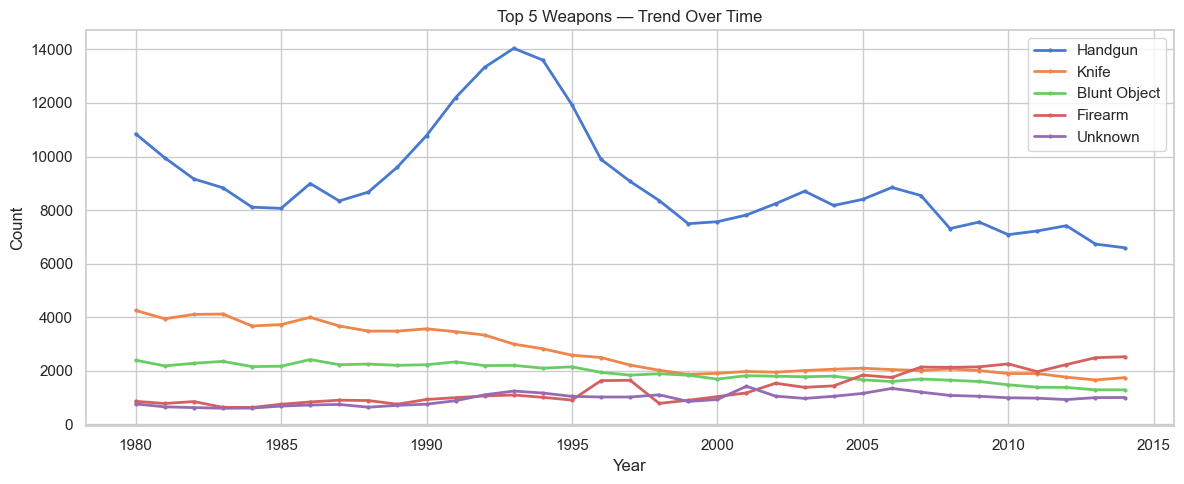

In [13]:
# Weapon trends over time (top 5)
top5 = df['Weapon'].value_counts().head(5).index

fig, ax = plt.subplots(figsize=(12, 5))
for w in top5:
    yearly_w = df[df.Weapon == w].groupby('Year').size()
    ax.plot(yearly_w.index, yearly_w.values, lw=2, label=w, marker='o', markersize=2)
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.set_title('Top 5 Weapons — Trend Over Time')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Victim-Offender Relationship

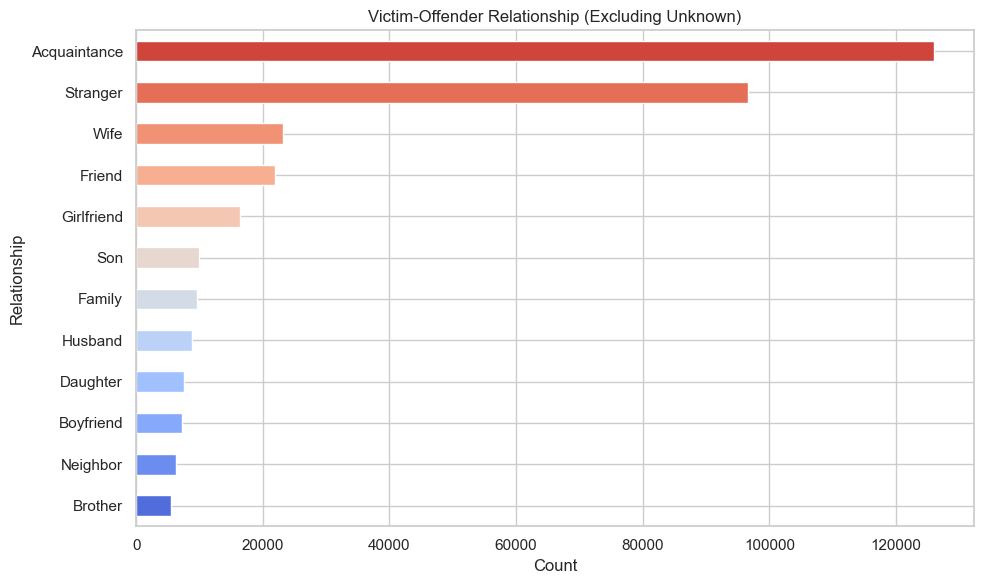

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
rel_counts = df[df.Relationship != 'Unknown']['Relationship'].value_counts().head(12)
rel_counts[::-1].plot(kind='barh', ax=ax, color=sns.color_palette("coolwarm", len(rel_counts)))
ax.set_xlabel('Count')
ax.set_title('Victim-Offender Relationship (Excluding Unknown)')
plt.tight_layout()
plt.show()

## 8. Geographic Distribution

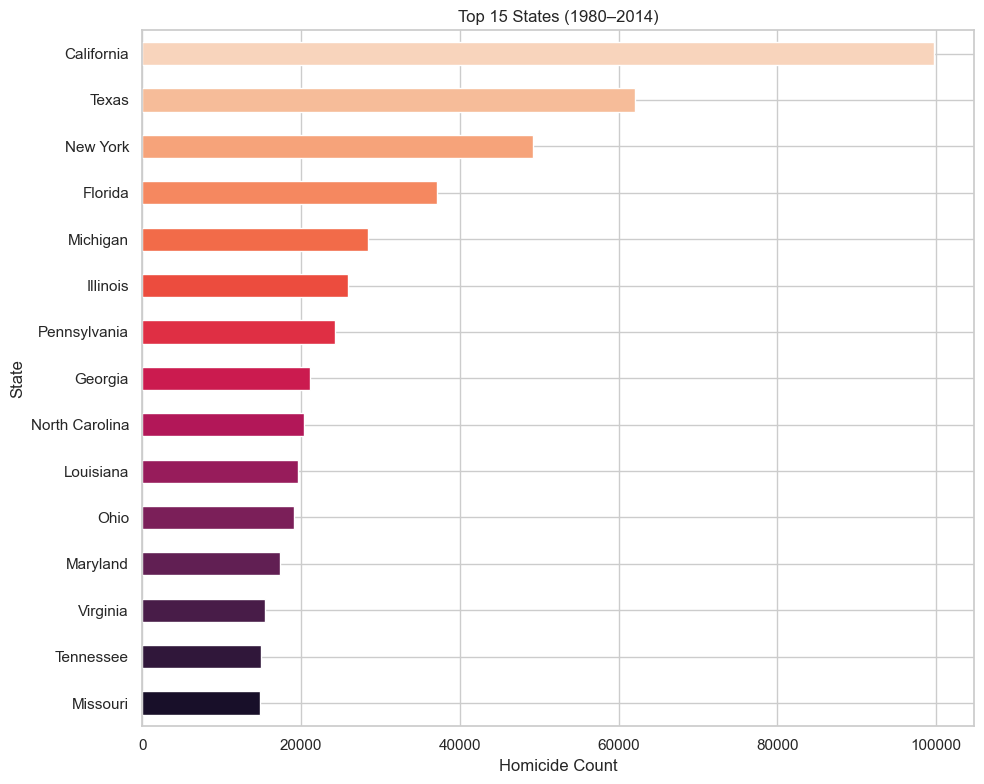

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))
state_counts = df['State'].value_counts().head(15)
state_counts[::-1].plot(kind='barh', ax=ax, color=sns.color_palette("rocket", len(state_counts)))
ax.set_xlabel('Homicide Count')
ax.set_title('Top 15 States (1980–2014)')
plt.tight_layout()
plt.show()

## 9. Clearance Rate by Weapon Type

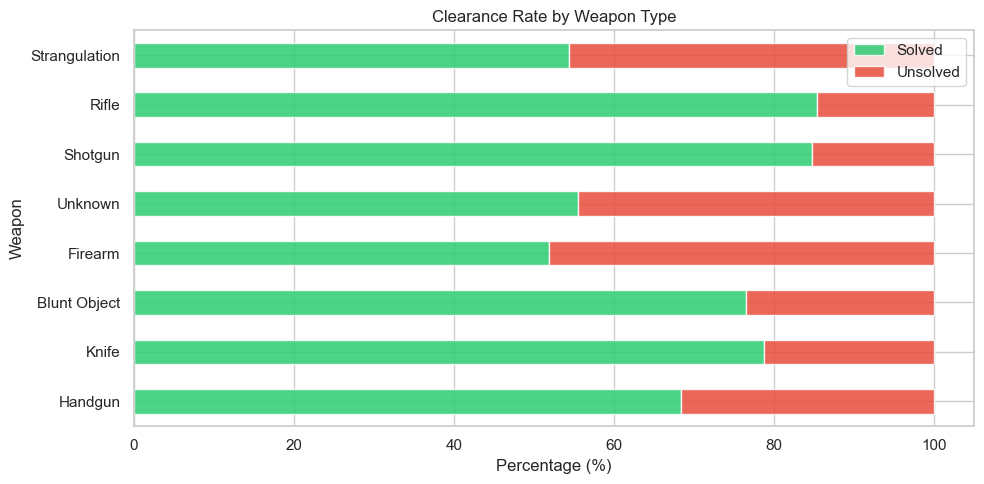

In [16]:
top_w = df['Weapon'].value_counts().head(8).index
cross = pd.crosstab(df[df.Weapon.isin(top_w)]['Weapon'], df['Crime Solved'])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
cross_pct = cross_pct.reindex(top_w)

fig, ax = plt.subplots(figsize=(10, 5))
cross_pct[['Yes', 'No']].plot(kind='barh', stacked=True, ax=ax,
                               color=['#2ecc71', '#e74c3c'], alpha=0.85)
ax.set_xlabel('Percentage (%)')
ax.set_title('Clearance Rate by Weapon Type')
ax.legend(['Solved', 'Unsolved'])
plt.tight_layout()
plt.show()

## 10. Weapon × Relationship Heatmap

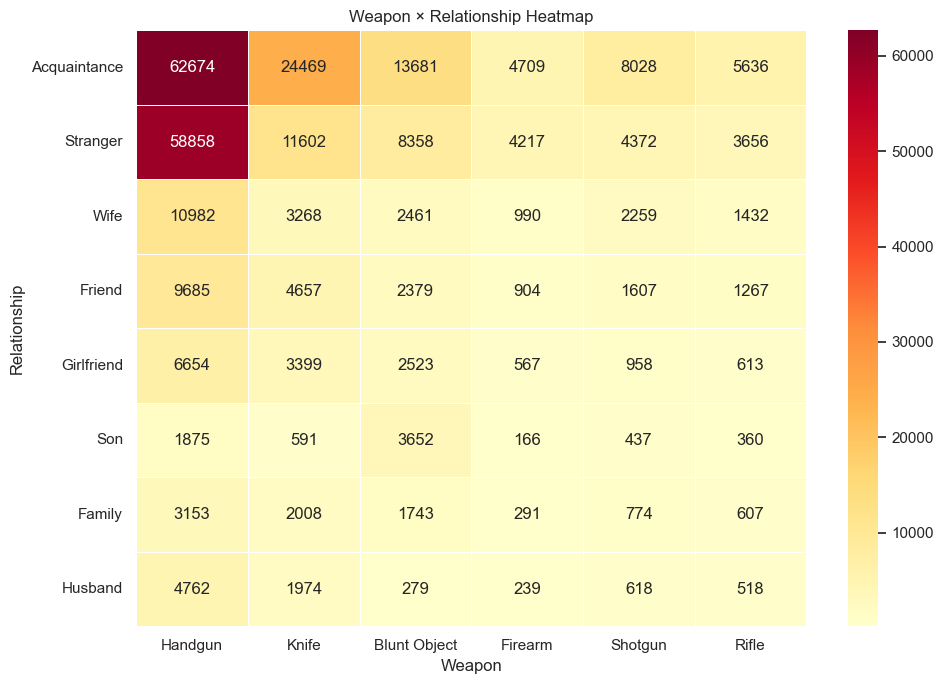

In [17]:
top_rel = df[df.Relationship != 'Unknown']['Relationship'].value_counts().head(8).index
top_weap = df[df.Weapon != 'Unknown']['Weapon'].value_counts().head(6).index

cross2 = pd.crosstab(
    df[df.Relationship.isin(top_rel)]['Relationship'],
    df[df.Weapon.isin(top_weap)]['Weapon']
)
cross2 = cross2.reindex(index=top_rel, columns=top_weap).fillna(0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cross2, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Weapon × Relationship Heatmap')
plt.tight_layout()
plt.show()

## 11. Feature Domain Mapping Summary

How this dataset maps to the four feature domains of the crime linkage model:

| Domain | Available Fields | Notes |
|--------|-----------------|-------|
| **Spatial** | State, City, Agency Code | No lat/lon — geocoding needed for OSRM network distance |
| **Temporal** | Year, Month | Month-level only — no exact dates limits temporal distance precision |
| **MO / Categorical** | Weapon, Crime Type, Relationship | Weapon works well for Jaccard distance; limited behavioral detail |
| **Victimological** | Victim Sex, Age, Race, Ethnicity | Good coverage; mix of nominal + ratio types fits Gower dissimilarity |

### Key Limitations
- **No coordinates** — spatial distance computation requires geocoding City+State pairs first
- **Month granularity** — temporal distances can only be approximated to ~15-day precision
- **Thin MO detail** — no crime scene behavior, entry method, or signature data (unlike ViCLAS)
- **No series labels** — ground truth for linked series must be inferred from solved cases with shared perpetrator info